# Censored data and robust links

A likelihood needs the CDF, not just the density, the moment any
observation is a bound rather than a value: "below the detection
limit", "at least k successes", "survived past t". For Gaussian models
numpyro has everything; for Beta, Gamma or Student-t observations the
CDFs either are missing from jax or have no parameter gradients, which
rules out both NUTS and SVI. `betainc_fn` and `stdtr` fill that gap:
both are differentiable in their shape parameters.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import chebax

## Beta observations with a detection limit

A lab measures proportions (impurity fractions, methylation levels,
volume fractions) but reports anything below 0.15 only as "< 0.15".
We simulate 300 draws from Beta(2, 6) and censor accordingly: what
remains is the uncensored values plus a *count* of censored ones.

In [2]:
rng = np.random.default_rng(3)
full = rng.beta(2.0, 6.0, size=300)
LOD = 0.15
observed = jnp.asarray(full[full >= LOD])
n_cens = int((full < LOD).sum())
true_mean = 2.0 / (2.0 + 6.0)
print(f"{len(observed)} observed values, {n_cens} censored below {LOD}")

216 observed values, 84 censored below 0.15


Each censored observation contributes log I_LOD(a, b) to the
likelihood, the log CDF of the Beta at the detection limit. That term
is `betainc_fn`, and because it has gradients in (a, b), NUTS works.

In [3]:
def model_censored(obs, n_cens):
    a = numpyro.sample("a", dist.Uniform(0.2, 100.0))
    b = numpyro.sample("b", dist.Uniform(0.2, 100.0))
    numpyro.sample("obs", dist.Beta(a, b), obs=obs)
    numpyro.factor("cens", n_cens * jnp.log(chebax.betainc_fn(a, b, LOD)))


def model_naive(obs, n_cens):  # pretend the censored points never existed
    a = numpyro.sample("a", dist.Uniform(0.2, 100.0))
    b = numpyro.sample("b", dist.Uniform(0.2, 100.0))
    numpyro.sample("obs", dist.Beta(a, b), obs=obs)


posts = {}
for name, m in [("censored", model_censored), ("naive", model_naive)]:
    mcmc = MCMC(NUTS(m), num_warmup=800, num_samples=1500, progress_bar=False)
    mcmc.run(jax.random.PRNGKey(0), observed, n_cens)
    posts[name] = mcmc.get_samples()

E0801 13:47:21.477917 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_0.6
E0801 13:47:21.594758 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_1.7


E0801 13:47:21.711475 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_2.8
E0801 13:47:21.850184 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_3.9


E0801 13:47:40.306870 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_19.44
E0801 13:47:40.419884 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_20.45


E0801 13:47:40.531580 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_21.46
E0801 13:47:40.654787 1166813 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_22.47


censored  posterior E[x]: mean 0.2480, 90% [0.2338, 0.2626]
naive     posterior E[x]: mean 0.3104, 90% [0.2966, 0.3235]


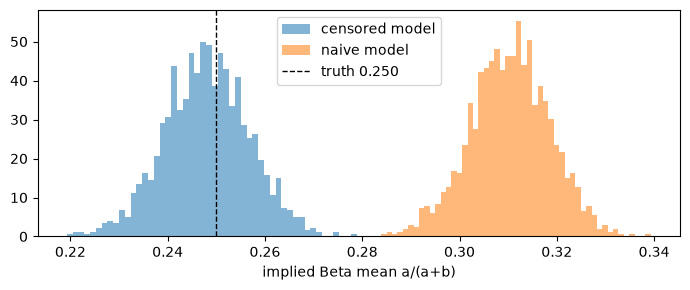

In [4]:
plt.figure(figsize=(7, 3))
for name, s in posts.items():
    mean = np.asarray(s["a"] / (s["a"] + s["b"]))
    plt.hist(mean, bins=50, density=True, alpha=0.55, label=f"{name} model")
    print(f"{name:9s} posterior E[x]: mean {mean.mean():.4f}, "
          f"90% [{np.quantile(mean, 0.05):.4f}, {np.quantile(mean, 0.95):.4f}]")
plt.axvline(true_mean, color="k", lw=1, ls="--", label=f"truth {true_mean:.3f}")
plt.xlabel("implied Beta mean a/(a+b)")
plt.legend()
plt.tight_layout()

Dropping the censored points biases the estimated mean upward (the
small values are exactly the ones that vanished); the censored model
recovers the truth. The same one-line `numpyro.factor` pattern covers
interval censoring (a difference of two `betainc_fn` calls) and
right-censored Gamma waiting times via `jax.scipy.special.gammainc`
with `gammaincinv` for posterior predictive quantiles.

## Robit regression: a Student-t link with learnable tails

Binary regression with a logistic or probit link is fragile to
mislabeled points: one flipped label at extreme x drags the whole
curve. The classic fix is the "robit" link, the Student-t CDF, whose
heavy tails let the model write off contradictory points cheaply. It
needs the t CDF differentiable in the degrees of freedom; that is
`stdtr(nu, t)` with nu traceable, so nu can even be a latent the data
chooses.

We simulate a clean logistic relationship, then flip 8 labels on the
right edge.

In [5]:
n = 120
x = jnp.asarray(np.sort(rng.uniform(-3, 3, n)))
p_true = jax.nn.sigmoid(2.0 * x)
y = jnp.asarray((rng.uniform(size=n) < np.asarray(p_true)).astype(float))
flip = np.zeros(n, bool)
flip[-8:] = True  # the 8 largest x: force failures where success is near-certain
y = jnp.asarray(np.where(flip, 0.0, np.asarray(y)))


def model_logit(x, y):
    b0 = numpyro.sample("b0", dist.Normal(0, 5))
    b1 = numpyro.sample("b1", dist.Normal(0, 5))
    numpyro.sample("y", dist.Bernoulli(logits=b0 + b1 * x), obs=y)


def model_robit(x, y):
    b0 = numpyro.sample("b0", dist.Normal(0, 5))
    b1 = numpyro.sample("b1", dist.Normal(0, 5))
    nu = numpyro.sample("nu", dist.Uniform(0.3, 150.0))
    p = chebax.stdtr(nu, b0 + b1 * x)
    numpyro.sample("y", dist.Bernoulli(probs=jnp.clip(p, 1e-12, 1 - 1e-12)), obs=y)


fits = {}
for name, m in [("logit", model_logit), ("robit", model_robit)]:
    mcmc = MCMC(NUTS(m), num_warmup=800, num_samples=1500, progress_bar=False)
    mcmc.run(jax.random.PRNGKey(1), x, y)
    fits[name] = mcmc.get_samples()

# the two links live on different scales, so compare what they predict
xq = jnp.asarray([0.0, 1.5, 2.5])
print("posterior mean P(y=1) at x = 0, 1.5, 2.5:")
print(f"{'truth':6s}", np.round(np.asarray(jax.nn.sigmoid(2.0 * xq)), 3))
for name, s in fits.items():
    if "nu" in s:
        pm = jax.vmap(lambda b0, b1, nu: chebax.stdtr(nu, b0 + b1 * xq))(
            s["b0"], s["b1"], s["nu"]).mean(0)
        extra = f"   (nu posterior mean {float(s['nu'].mean()):.2f})"
    else:
        pm = jax.nn.sigmoid(s["b0"][:, None] + s["b1"][:, None] * xq[None, :]).mean(0)
        extra = ""
    print(f"{name:6s}", np.round(np.asarray(pm), 3), extra)

posterior mean P(y=1) at x = 0, 1.5, 2.5:


truth  [0.5   0.953 0.993]
logit  [0.399 0.731 0.872] 


robit  [0.604 0.87  0.894]    (nu posterior mean 0.43)


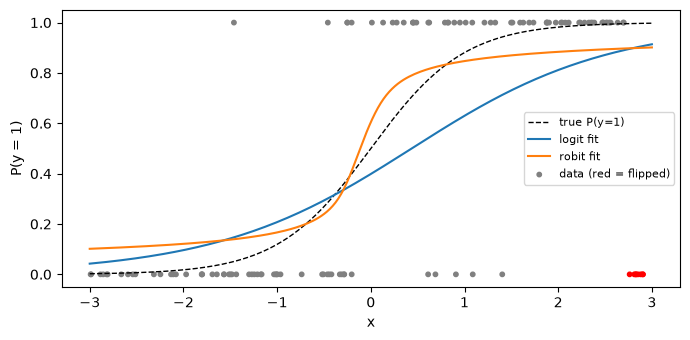

In [6]:
xg = jnp.linspace(-3, 3, 200)
plt.figure(figsize=(7, 3.5))
plt.plot(xg, jax.nn.sigmoid(2.0 * xg), "k--", lw=1, label="true P(y=1)")
s = fits["logit"]
curve = jax.nn.sigmoid(s["b0"][:, None] + s["b1"][:, None] * xg[None, :]).mean(0)
plt.plot(xg, curve, label="logit fit")
s = fits["robit"]
curve = jax.vmap(lambda b0, b1, nu: chebax.stdtr(nu, b0 + b1 * xg))(
    s["b0"], s["b1"], s["nu"]).mean(0)
plt.plot(xg, curve, label="robit fit")
plt.scatter(np.asarray(x), np.asarray(y), s=10, c=np.where(flip, "r", "gray"),
            label="data (red = flipped)")
plt.xlabel("x")
plt.ylabel("P(y = 1)")
plt.legend(loc="center right", fontsize=8)
plt.tight_layout()

The logistic fit bends toward the flipped labels; the robit fit keeps
the transition sharp and absorbs them in the tails, with the posterior
over nu concentrating on small values because the data demand heavy
tails. On clean data the same model lets nu drift large, recovering the
probit. Other likelihood terms this unlocks the same way: "at least k
of n" observations via the binomial tail I_p(k, n-k+1), and tobit-style
censored regression with Student-t noise via `stdtr`.